In [1]:
!pip install python-calamine

In [2]:
import pandas as pd


def explore_dataset(file_path):
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)

        
    elif file_path.endswith('.xlsx'):
        df = pd.read_excel(file_path, engine='calamine')

        
    else:
        print("Unsupported file format.")
        return


    
    print(" Dataset Information :")
    print(df.info())
    
    print("\n First 5 Rows :")
    print(df.head())
    
    print("\n Summary Statistics :")
    print(df.describe())

    print("\n Missing Values :")
    print(df.isnull().sum())

    print("\n Unique Values :")
    for column in df.select_dtypes(include='object').columns:
       
        uniques = df[column].unique()[:50]
        print(f"{column} (showing up to 50): {uniques}")


file_path = r'C:\Users\Jithu\OneDrive\Documents\customersegmentation\OnlineRetail.xlsx'
explore_dataset(file_path)

 Dataset Information :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

 First 5 Rows :
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS 

In [3]:
import pandas as pd

def clean_retail_data(file_path):

    if file_path.endswith('.xlsx'):
        df = pd.read_excel(file_path, engine='calamine')
    
    else:
        df = pd.read_csv(file_path)
    
    initial_rows = len(df)
    print(f"total row count: {initial_rows:,}")

    
    df = df[(df['Quantity'] > 0) & (df['Quantity'] <= 300)]
    df = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] <= 50)]


    df = df.dropna(subset=['CustomerID'])
    
    
    df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
    
    
    df = df.drop_duplicates()
    
    
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    
    
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

    
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


    df['Invoice_Date'] = df['InvoiceDate'].dt.date


    df['Invoice_Time'] = df['InvoiceDate'].dt.time

    df.drop('InvoiceDate', axis=1, inplace=True)

    final_rows = len(df)
    
    print("\n Cleaning Summary :")
    print(f"Rows dropped: {initial_rows - final_rows:,}")
    print(f"Final clean row count: {final_rows:,}")
    print(f"Missing values after clean:\n{df.isnull().sum()}")
    print(f"summary stats")
    print(df.describe())
    print(df[[ 'Invoice_Date', 'Invoice_Time']].head())
    
    return df


file_path = r'C:\Users\Jithu\OneDrive\Documents\customersegmentation\OnlineRetail.xlsx'
df_clean = clean_retail_data(file_path)

total row count: 541,909

 Cleaning Summary :
Rows dropped: 150,312
Final clean row count: 391,597
Missing values after clean:
InvoiceNo       0
StockCode       0
Description     0
Quantity        0
UnitPrice       0
CustomerID      0
Country         0
TotalAmount     0
Invoice_Date    0
Invoice_Time    0
dtype: int64
summary stats
            Quantity      UnitPrice    TotalAmount
count  391597.000000  391597.000000  391597.000000
mean       11.332053       2.889578      20.047163
std        21.924303       3.215876      45.951639
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      11.900000
75%        12.000000       3.750000      19.800000
max       300.000000      50.000000    3285.000000
  Invoice_Date Invoice_Time
0   2010-12-01     08:26:00
1   2010-12-01     08:26:00
2   2010-12-01     08:26:00
3   2010-12-01     08:26:00
4   2010-12-01     08:26:00


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def transform_cleaned_retail_data(df_input):
    df_transformed = df_input.copy()
    
    
    if 'Country' in df_transformed.columns:
        print("Encoding categorical 'Country' column:")
        encoder = OneHotEncoder(sparse_output=False, drop='first')
        country_encoded = encoder.fit_transform(df_transformed[['Country']])
        encoded_cols = encoder.get_feature_names_out(['Country'])
        df_encoded_countries = pd.DataFrame(country_encoded, columns=encoded_cols, index=df_transformed.index)
        df_transformed = df_transformed.drop('Country', axis=1)
        df_transformed = pd.concat([df_transformed, df_encoded_countries], axis=1)

    
    numeric_cols = ['Quantity', 'UnitPrice', 'TotalAmount']
    if all(col in df_transformed.columns for col in numeric_cols):
        print(" Log Transformation :")
        for col in numeric_cols:
            df_transformed[col] = np.log1p(df_transformed[col])
            
    
    if all(col in df_transformed.columns for col in numeric_cols):
        print("Standardizing numerical ranges:")
        scaler = StandardScaler()
        df_transformed[numeric_cols] = scaler.fit_transform(df_transformed[numeric_cols])
        
    print("Transformation complete!")
    return df_transformed


if 'df_clean' in locals():
    final_transformed_df = transform_cleaned_retail_data(df_clean)
    
    
    print("Final Transformed :")
    print(final_transformed_df.head(50))
else:
    print("'df_clean' was not found")


Encoding categorical 'Country' column:
 Log Transformation :
Standardizing numerical ranges:
Transformation complete!
Final Transformed :
   InvoiceNo StockCode                          Description  Quantity  \
0     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER  0.025558   
1     536365     71053                  WHITE METAL LANTERN  0.025558   
2     536365    84406B       CREAM CUPID HEARTS COAT HANGER  0.282042   
3     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE  0.025558   
4     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.  0.025558   
5     536365     22752         SET 7 BABUSHKA NESTING BOXES -0.839169   
6     536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER  0.025558   
7     536366     22633               HAND WARMER UNION JACK  0.025558   
8     536366     22632            HAND WARMER RED POLKA DOT  0.025558   
9     536367     84879        ASSORTED COLOUR BIRD ORNAMENT  1.608051   
10    536367     22745           POPPY'S PLAYHOUSE BEDROOM 

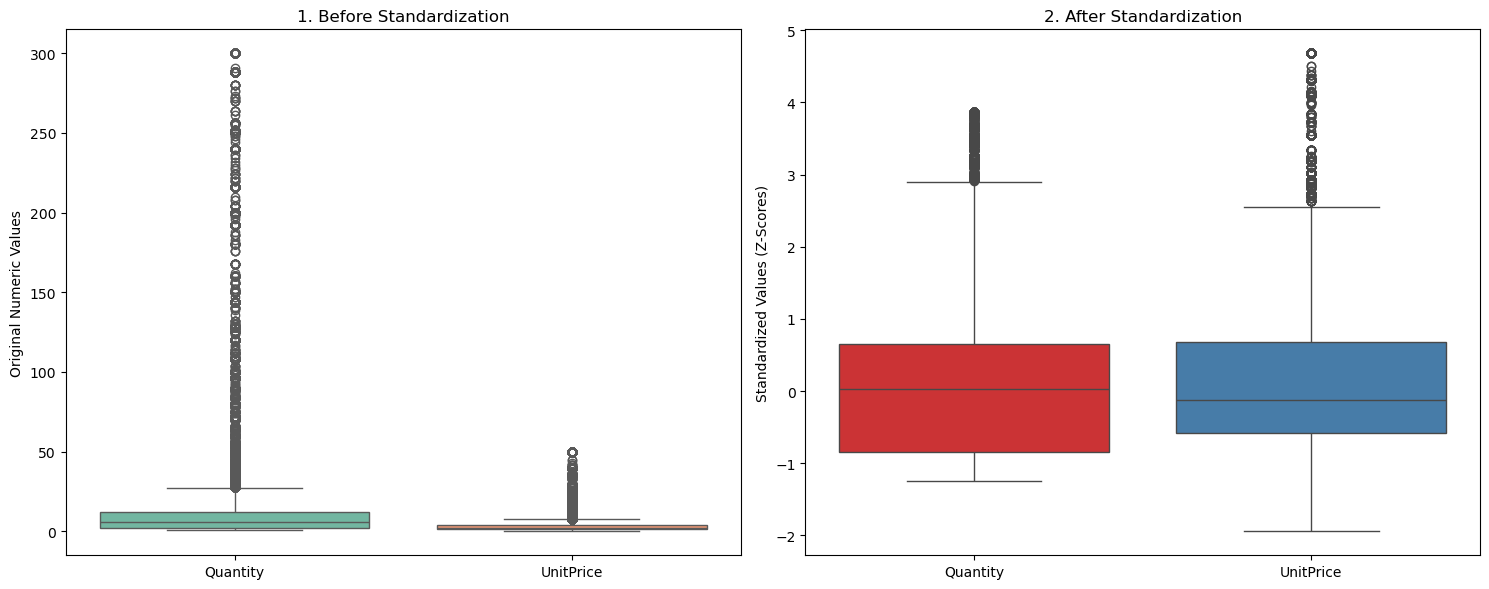

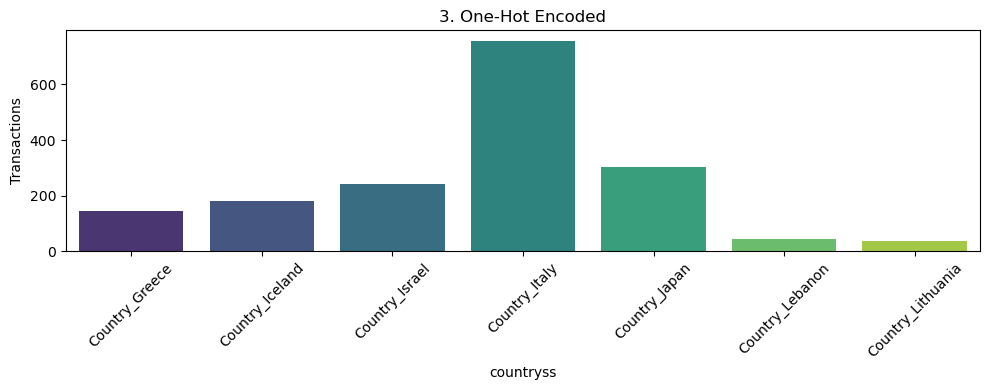

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.boxplot(data=df_clean[['Quantity', 'UnitPrice']], ax=axes[0], palette="Set2")
axes[0].set_title("1. Before Standardization", fontsize=12)
axes[0].set_ylabel("Original Numeric Values")


sns.boxplot(data=final_transformed_df[['Quantity', 'UnitPrice']], ax=axes[1], palette="Set1")
axes[1].set_title("2. After Standardization", fontsize=12)
axes[1].set_ylabel("Standardized Values (Z-Scores)")


plt.tight_layout()
plt.show()


country_cols = [col for col in final_transformed_df.columns if 'Country_' in col][14:21] 

if country_cols:
    plt.figure(figsize=(10, 4))
    
    encoded_counts = final_transformed_df[country_cols].sum()
    
    
    sns.barplot(x=encoded_counts.index, y=encoded_counts.values, hue=encoded_counts.index, palette="viridis", legend=False)
    
    plt.title("3. One-Hot Encoded", fontsize=12)
    plt.xticks(rotation=45)
    plt.ylabel("Transactions")
    plt.xlabel("countryss")
    plt.tight_layout()
    plt.show()
else:
    print("failure")


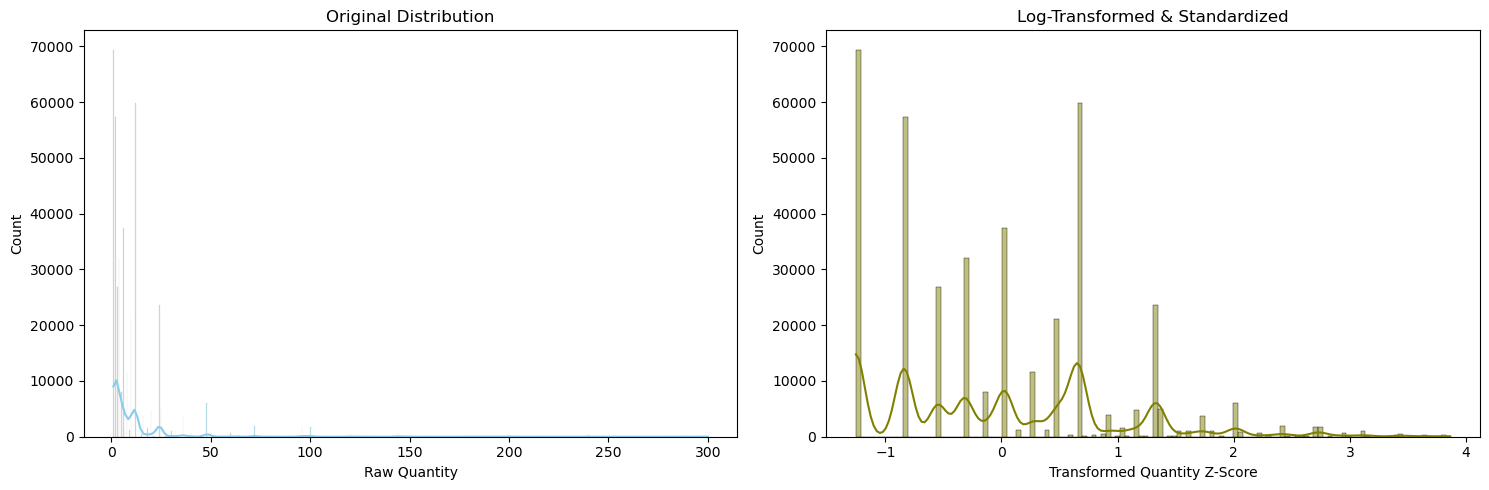

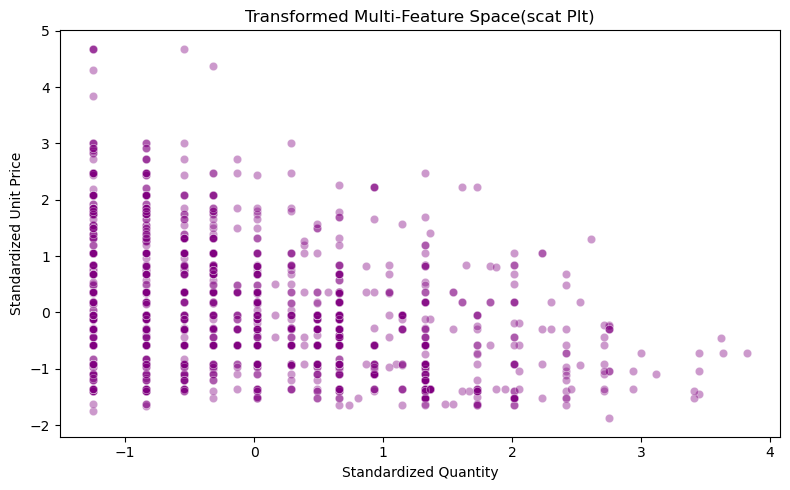

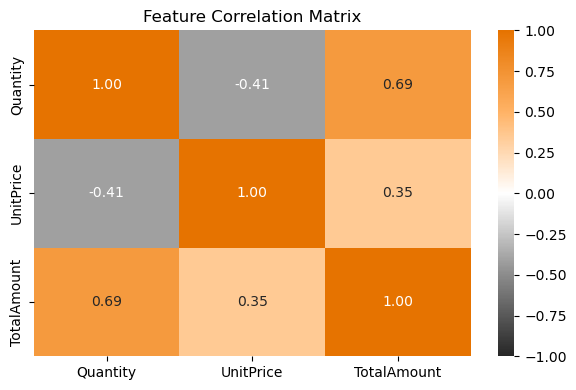

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap  
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.histplot(df_clean['Quantity'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Original Distribution")
axes[0].set_xlabel("Raw Quantity")


sns.histplot(final_transformed_df['Quantity'], kde=True, ax=axes[1], color='olive')
axes[1].set_title("Log-Transformed & Standardized")
axes[1].set_xlabel("Transformed Quantity Z-Score")

plt.tight_layout()
plt.show()



plt.figure(figsize=(8, 5))

sns.scatterplot(data=final_transformed_df.sample(2000, random_state=42), 
                x='Quantity', y='UnitPrice', alpha=0.4, color='purple')
plt.title("Transformed Multi-Feature Space(scat Plt)")
plt.xlabel("Standardized Quantity")
plt.ylabel("Standardized Unit Price")
plt.tight_layout()
plt.show()



custom_colors = ["#262626", "#8C8C8C", "#FFFFFF", "#FFB366", "#E67300"]

orange_grey_cmap = LinearSegmentedColormap.from_list("RichOrangeGrey", custom_colors)

plt.figure(figsize=(6, 4))
numeric_features = ['Quantity', 'UnitPrice', 'TotalAmount']
correlation_matrix = final_transformed_df[numeric_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap=orange_grey_cmap, fmt=".2f", vmin=-1, vmax=1)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [7]:
import os
print(" notebook is ")
print(os.getcwd())


 notebook is 
C:\Users\Jithu\Pavanjith_customer_segmentation_mentormind


In [8]:
import pandas as pd
import datetime as dt
from sklearn.preprocessing import StandardScaler


df_clean['Invoice_Date'] = pd.to_datetime(df_clean['Invoice_Date']).dt.date
snapshot_date = df_clean['Invoice_Date'].max() + dt.timedelta(days=1)


customer_rfm = df_clean.groupby('CustomerID').agg({'Invoice_Date': lambda x: (snapshot_date - x.max()).days, 'InvoiceNo': 'nunique', 'TotalAmount': 'sum'})

customer_rfm.columns = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()
customer_scaled = pd.DataFrame(
    scaler.fit_transform(customer_rfm),
    columns=customer_rfm.columns,
    index=customer_rfm.index
)

print("Customerlevel RFM and standardized,success")
print(customer_scaled.head())


Customerlevel RFM and standardized,success
             Recency  Frequency  Monetary
CustomerID                               
12347      -0.900804   0.362285  0.356746
12348      -0.170833  -0.031797 -0.003286
12349      -0.740810  -0.425879 -0.051957
12350       2.179075  -0.425879 -0.212884
12352      -0.560817   0.362285 -0.022127


WCSS for k = 1 to 10...


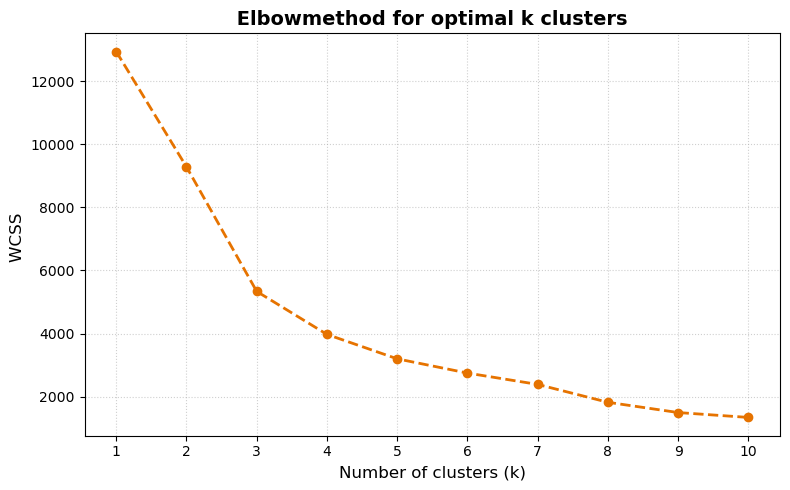

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


wcss = []

print("WCSS for k = 1 to 10...")
for k in range(1, 11):

    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    
    
    kmeans.fit(customer_scaled)
    
    
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='#E67300', linewidth=2)


plt.title(" Elbowmethod for optimal k clusters ", fontsize=14, fontweight='bold')
plt.xlabel("Number of clusters (k)", fontsize=12)
plt.ylabel("WCSS ", fontsize=12)
plt.xticks(range(1, 11))  
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


In [10]:
from sklearn.cluster import KMeans

model_kmeans = KMeans(n_clusters=3, random_state=42)

customer_clusters = model_kmeans.fit_predict(customer_scaled)

customer_rfm['Cluster'] = customer_clusters


print("Model training complete!")
print("Segmented Customers")
print(customer_rfm.head(30))


Model training complete!
Segmented Customers
            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12347             3          7   4310.00        0
12348            76          4   1797.24        0
12349            19          1   1457.55        0
12350           311          1    334.40        1
12352            37          7   1665.74        0
12353           205          1     89.00        1
12354           233          1   1079.40        1
12355           215          1    459.40        1
12356            23          3   2811.43        0
12357            34          1   6207.67        0
12358             2          2   1168.06        0
12359            58          4   5060.03        0
12360            53          3   2662.06        0
12361           288          1    189.90        1
12362             4         10   5226.23        0
12363           110          2    552.00        0
12364             8          4   1313.10        0
12365

In [19]:
import pandas as pd
from sklearn.cluster import KMeans


model_kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
customer_clusters = model_kmeans.fit_predict(customer_scaled)


customer_rfm['Cluster'] = customer_clusters

print("SEGMENT CHARACTERISTICS MATRIX:")

segment_statistics = customer_rfm.groupby('Cluster').agg({'Recency': ['mean', 'median', 'std'],'Frequency': ['mean', 'median', 'std'],'Monetary': ['mean', 'median', 'std']})

print(segment_statistics.round(2))



SEGMENT CHARACTERISTICS MATRIX:
        Recency               Frequency                Monetary            \
           mean median    std      mean median    std      mean    median   
Cluster                                                                     
0         41.66   31.0  35.23      4.69    3.0   5.19   1827.03    904.70   
1        246.71  242.0  67.34      1.57    1.0   1.45    460.47    306.94   
2          7.15    3.0   9.74     77.00   59.0  49.70  74484.64  55445.91   

                   
              std  
Cluster            
0         3142.25  
1          610.80  
2        60874.62  


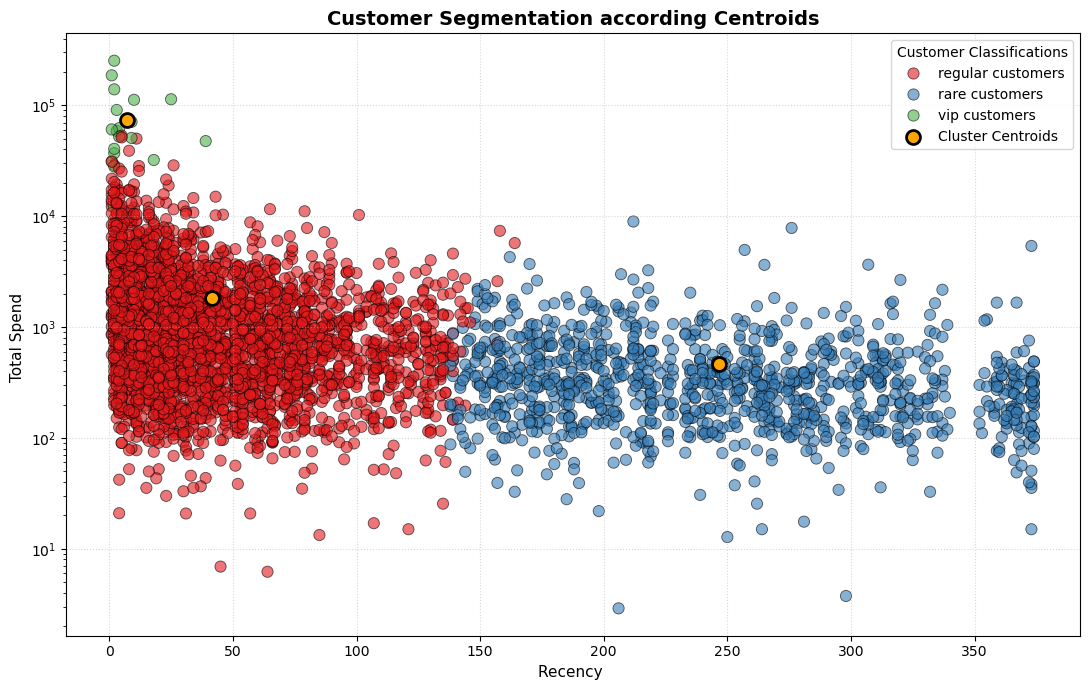

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

df_visual = customer_rfm.copy()

cluster_map = {2: 'vip customers',0: 'regular customers',1: 'rare customers'}
df_visual['Customer Segment'] = df_visual['Cluster'].map(cluster_map)


centroid_x = [7.15, 41.66, 246.71]
centroid_y = [74484.64, 1827.03, 460.47]


plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_visual, x='Recency', y='Monetary', hue='Customer Segment', palette='Set1', alpha=0.6, edgecolor='k', s=65)

plt.scatter(centroid_x, centroid_y, color='orange', marker='.', s=400, edgecolor='black', linewidth=2, label='Cluster Centroids')
plt.yscale('log') 
plt.title("Customer Segmentation according Centroids", fontsize=14, fontweight='bold')
plt.xlabel("Recency ", fontsize=11)
plt.ylabel("Total Spend ", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title="Customer Classifications", loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


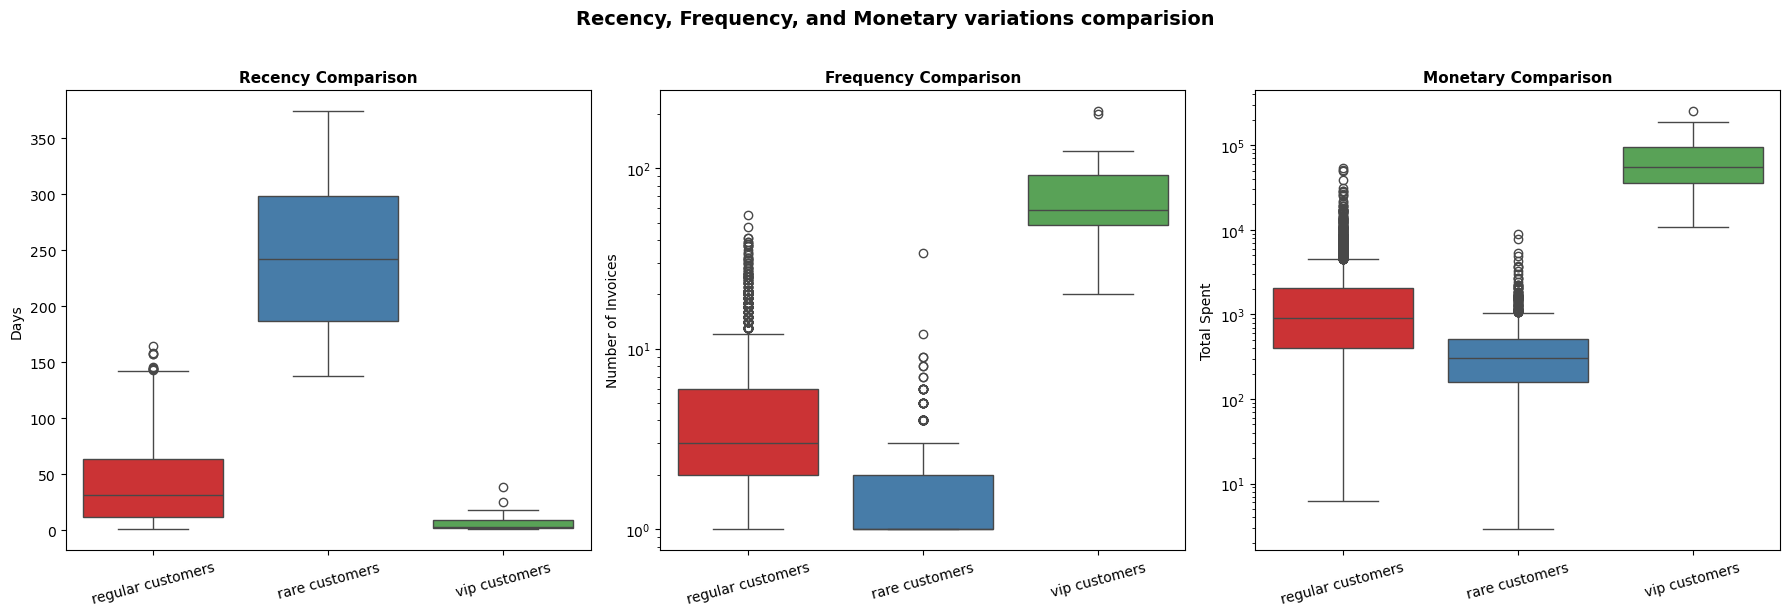

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns


df_box_visual = customer_rfm.copy()
cluster_map = {2: 'vip customers',0: 'regular customers',1: 'rare customers'}

df_box_visual['Customer Segment'] = df_box_visual['Cluster'].map(cluster_map)

custom_segment_palette = {'regular customers': '#E41A1C', 'rare customers': '#377EB8', 'vip customers': '#4DAF4A'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df_box_visual, x='Customer Segment', y='Recency', ax=axes[0], palette=custom_segment_palette, hue='Customer Segment', legend=False)
axes[0].set_title("Recency Comparison", fontsize=11, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis='x', rotation=15)



sns.boxplot(data=df_box_visual, x='Customer Segment', y='Frequency', ax=axes[1], palette=custom_segment_palette, hue='Customer Segment', legend=False)
axes[1].set_yscale('log')
axes[1].set_title("Frequency Comparison", fontsize=11, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Invoices")
axes[1].tick_params(axis='x', rotation=15)



sns.boxplot(data=df_box_visual, x='Customer Segment', y='Monetary', ax=axes[2], palette=custom_segment_palette, hue='Customer Segment', legend=False)
axes[2].set_yscale('log')
axes[2].set_title("Monetary Comparison", fontsize=11, fontweight='bold')
axes[2].set_xlabel("")
axes[2].set_ylabel("Total Spent")
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle("Recency, Frequency, and Monetary variations comparision", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [30]:
import pandas as pd

cluster_map = {2: 'vip customers',0: 'regular customers',1: 'rare customers'}
customer_rfm['Customer_Segment'] = customer_rfm['Cluster'].map(cluster_map)


customer_rfm.to_excel('mentor_mind_project_customer_segment_completed.xlsx', index=True)

print("exported to excel")



exported to excel
